# 📊 Understanding PageRank with NetworkX

**An Interactive Educational Notebook**

---

## Introduction

**PageRank** is one of the most famous graph algorithms ever created. Originally developed by Larry Page and Sergey Brin to rank web pages in Google Search, it has since been applied to social networks, citation analysis, biology, and more.

At its core, PageRank answers a simple question:

> *"If you randomly surfed the web forever, following links at random, which pages would you visit most often?"*

Pages that are linked to by many other important pages will be visited more often — and therefore receive a higher PageRank score.

### What You'll Learn

By the end of this notebook, you will be able to:

- Explain the intuition behind the PageRank algorithm
- Construct and visualize directed graphs using NetworkX
- Compute and interpret PageRank scores
- Compare PageRank with other centrality measures
- Explore how the **damping factor** affects results
- Apply PageRank to a real-world social network dataset

---

## Section 1: Setup

We begin by importing the libraries we'll use throughout this notebook.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np

# Make plots look clean and consistent
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print("✅ Libraries loaded successfully!")
print(f"   NetworkX version: {nx.__version__}")

✅ Libraries loaded successfully!
   NetworkX version: 3.3


---

## Section 2: The Intuition Behind PageRank

### 2.1 Link-Based Importance

Imagine the web as a giant directed graph:
- Each **webpage** is a **node**
- Each **hyperlink** from page A → page B is a **directed edge**

The key insight of PageRank is:

> **A page is important if important pages link to it.**

This is a recursive definition — importance depends on the importance of those linking to you.

### 2.2 The Random Surfer Model

Think of a "random surfer" who:
1. Starts on a random webpage
2. Clicks a random outgoing link
3. Repeats forever

The **PageRank score** of a page = the fraction of time the surfer spends on that page over a very long time.

### 2.3 The Damping Factor

Real surfers don't follow links forever. Sometimes they get bored and jump to a completely random page. The **damping factor** `alpha` (typically **0.85**) models this behavior:

- With probability `alpha` → follow a random outgoing link
- With probability `1 - alpha` → teleport to any random page

The PageRank formula is:

$$PR(u) = \frac{1 - \alpha}{N} + \alpha \sum_{v \in In(u)} \frac{PR(v)}{Out(v)}$$

Where:
- $N$ = total number of nodes
- $In(u)$ = nodes with edges pointing to $u$
- $Out(v)$ = number of outgoing edges from $v$
- $\alpha$ = damping factor (default 0.85)

---

## Section 3: Building a Simple Graph

Let's create a small directed graph to make these ideas concrete.

We'll model a tiny "web" of 5 pages: A, B, C, D, E.

In [2]:
# Create a directed graph
G = nx.DiGraph()

# Add nodes (web pages)
nodes = ['A', 'B', 'C', 'D', 'E']
G.add_nodes_from(nodes)

# Add edges (hyperlinks between pages)
edges = [
    ('A', 'B'),  # A links to B
    ('A', 'C'),  # A links to C
    ('B', 'C'),  # B links to C
    ('C', 'A'),  # C links back to A
    ('D', 'C'),  # D links to C
    ('E', 'D'),  # E links to D
    ('E', 'B'),  # E links to B
    ('B', 'D'),  # B links to D
]
G.add_edges_from(edges)

print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
print(f"Nodes: {list(G.nodes())}")
print(f"Edges: {list(G.edges())}")

Graph created with 5 nodes and 8 edges
Nodes: ['A', 'B', 'C', 'D', 'E']
Edges: [('A', 'B'), ('A', 'C'), ('B', 'C'), ('B', 'D'), ('C', 'A'), ('D', 'C'), ('E', 'D'), ('E', 'B')]


### 3.1 Visualizing the Graph

Let's draw our directed graph to see its structure.

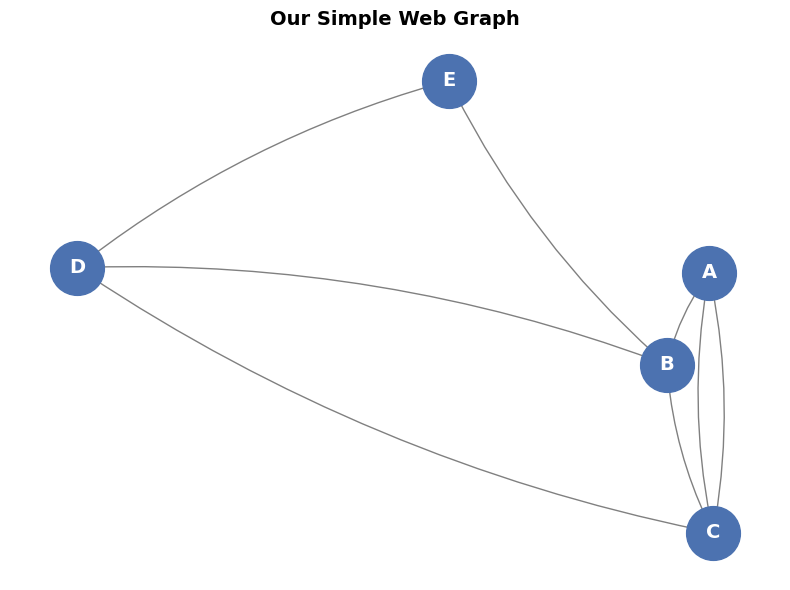

In [3]:
def draw_graph(G, title="Directed Graph", node_sizes=None, node_colors=None, ax=None):
    """Helper function to draw a directed graph with consistent styling."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    pos = nx.spring_layout(G, seed=42)  # Fixed seed for reproducibility
    
    if node_sizes is None:
        node_sizes = 1500
    if node_colors is None:
        node_colors = '#4C72B0'
    
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=14, font_color='white', font_weight='bold', ax=ax)
    nx.draw_networkx_edges(
        G, pos,
        edge_color='gray',
        arrows=True,
        arrowsize=20,
        arrowstyle='-|>',
        connectionstyle='arc3,rad=0.1',
        ax=ax
    )
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')
    return pos

# Draw the basic graph
fig, ax = plt.subplots(figsize=(8, 6))
draw_graph(G, title="Our Simple Web Graph", ax=ax)
plt.tight_layout()
plt.show()

**What do you notice?**
- Node **C** receives links from A, B, and D — it's a popular destination
- Node **E** has no incoming links — it can only send influence, never receive it
- There's a cycle: A → B → D ← E and C → A

These structural patterns will be reflected in the PageRank scores.

---

## Section 4: Computing PageRank

NetworkX makes it very easy to compute PageRank with a single function call.

In [4]:
# Compute PageRank scores
# alpha=0.85 is the standard damping factor
pagerank_scores = nx.pagerank(G, alpha=0.85)

# Display scores as a sorted DataFrame
pr_df = pd.DataFrame(
    list(pagerank_scores.items()),
    columns=['Node', 'PageRank Score']
).sort_values('PageRank Score', ascending=False).reset_index(drop=True)

pr_df['Rank'] = pr_df.index + 1
pr_df = pr_df[['Rank', 'Node', 'PageRank Score']]
pr_df['PageRank Score'] = pr_df['PageRank Score'].round(4)

print("📊 PageRank Scores (alpha=0.85)")
print("=" * 35)
print(pr_df.to_string(index=False))

📊 PageRank Scores (alpha=0.85)
 Rank Node  PageRank Score
    1    C          0.3460
    2    A          0.3241
    3    B          0.1805
    4    D          0.1195
    5    E          0.0300


### 4.1 Interpreting the Results

The scores tell us:
- **Node C** ranks highest — it receives links from multiple nodes (A, B, D)
- **Node A** ranks second — it benefits from the C → A feedback cycle
- **Node E** ranks lowest — no incoming links means no inherited importance

> 💡 **Key Insight:** PageRank is not just about how many links point to you, but also about *how important* those linking nodes are.

The PageRank score of node i is defined as:

PR(i) = (1 - d)/N + d * Σ (PR(j) / out_degree(j))
where:

d = damping factor
N = number of nodes
j = nodes linking to i

---

## Section 5: Visualizing Node Importance

We can make the PageRank scores visually intuitive by encoding them into **node size** and **node color**.

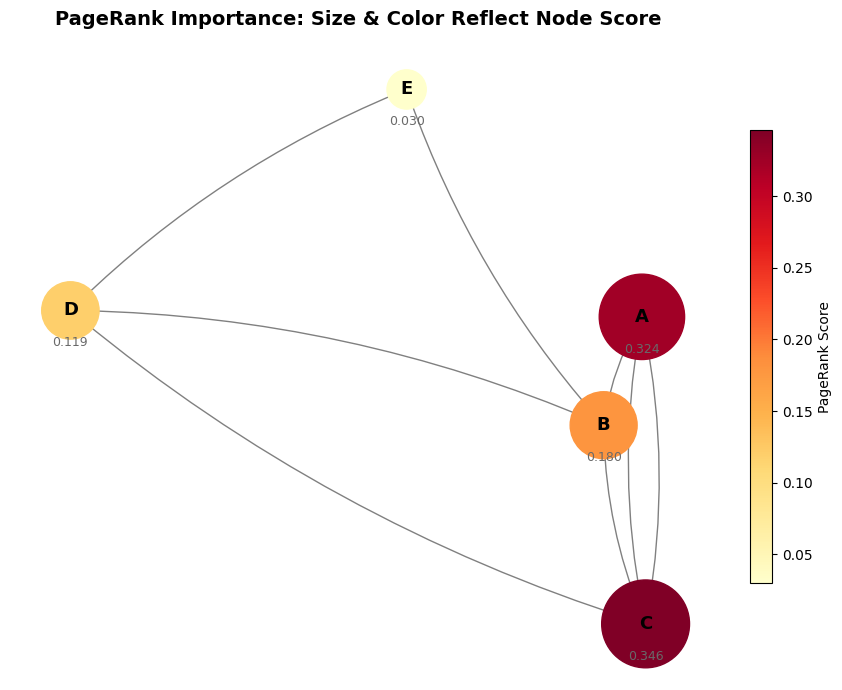

In [5]:
# Scale node sizes by PageRank score
scores = pagerank_scores
min_size, max_size = 800, 4000
score_values = np.array(list(scores.values()))
normalized = (score_values - score_values.min()) / (score_values.max() - score_values.min())
node_sizes = [min_size + n * (max_size - min_size) for n in normalized]

# Map scores to colors using a colormap
cmap = plt.cm.YlOrRd
node_colors = [cmap(n) for n in normalized]

# Draw the importance-encoded graph
fig, ax = plt.subplots(figsize=(9, 7))
pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=13, font_color='black', font_weight='bold', ax=ax)
nx.draw_networkx_edges(
    G, pos, edge_color='gray', arrows=True,
    arrowsize=20, arrowstyle='-|>', connectionstyle='arc3,rad=0.1', ax=ax
)

# Add PageRank score labels below each node
score_labels = {node: f"{score:.3f}" for node, score in scores.items()}
label_pos = {node: (x, y - 0.12) for node, (x, y) in pos.items()}
nx.draw_networkx_labels(G, label_pos, labels=score_labels, font_size=9, font_color='dimgray', ax=ax)

# Add a colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=score_values.min(), vmax=score_values.max()))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='PageRank Score', shrink=0.7)

ax.set_title("PageRank Importance: Size & Color Reflect Node Score", fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

**Observation:** Larger, darker nodes are more important in the network. You can now visually confirm that **C** is the most influential node.

---

## Section 6: Comparing Centrality Metrics

PageRank is one of several ways to measure node importance. Let's compare it with two others:

| Metric | What it measures |
|---|---|
| **Degree Centrality** | Fraction of nodes a node is connected to |
| **Betweenness Centrality** | How often a node lies on the shortest path between two others |
| **PageRank** | Recursive importance based on incoming link quality |


In [6]:
# Compute all three centrality metrics
pagerank    = nx.pagerank(G, alpha=0.85)
in_degree   = nx.in_degree_centrality(G)   # For directed graphs, use in-degree
betweenness = nx.betweenness_centrality(G)

# Build a comparison DataFrame
comparison_df = pd.DataFrame({
    'Node': list(G.nodes()),
    'PageRank': [round(pagerank[n], 4) for n in G.nodes()],
    'In-Degree Centrality': [round(in_degree[n], 4) for n in G.nodes()],
    'Betweenness Centrality': [round(betweenness[n], 4) for n in G.nodes()],
}).set_index('Node')

print("📊 Centrality Metric Comparison")
print("=" * 55)
print(comparison_df.to_string())

📊 Centrality Metric Comparison
      PageRank  In-Degree Centrality  Betweenness Centrality
Node                                                        
A       0.3241                  0.25                  0.2500
B       0.1805                  0.50                  0.2500
C       0.3460                  0.75                  0.3333
D       0.1195                  0.50                  0.0833
E       0.0300                  0.00                  0.0000


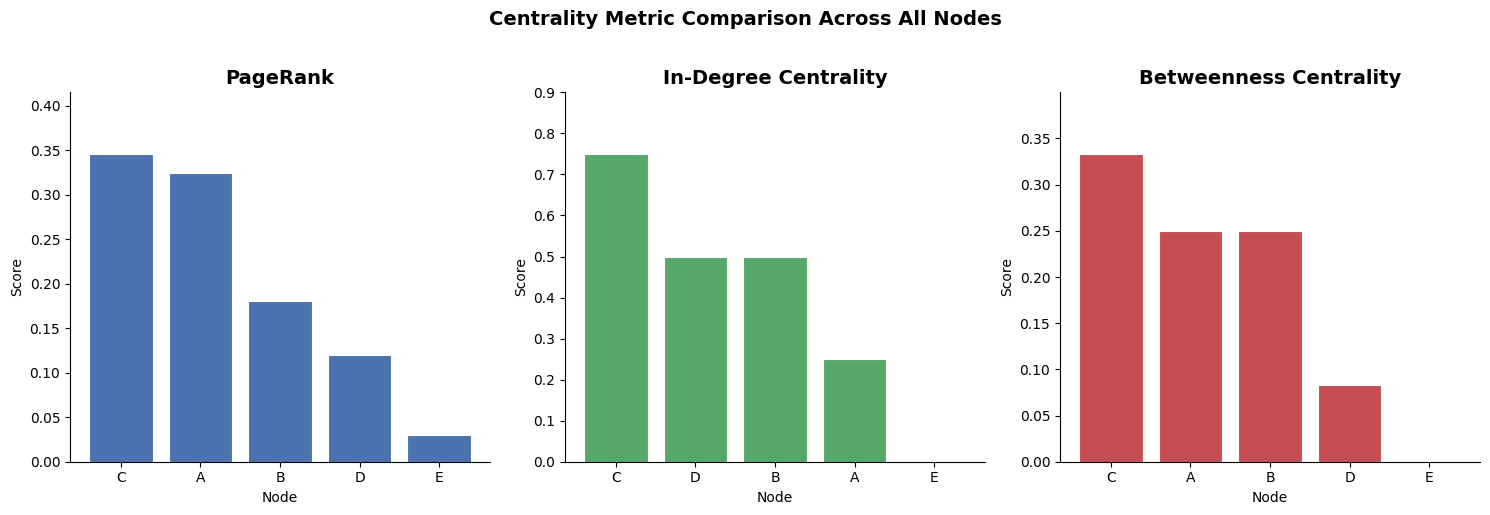

In [7]:
# Visualize centrality comparison as a bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#4C72B0', '#55A868', '#C44E52']
metrics = ['PageRank', 'In-Degree Centrality', 'Betweenness Centrality']

for ax, metric, color in zip(axes, metrics, colors):
    sorted_df = comparison_df[metric].sort_values(ascending=False)
    ax.bar(sorted_df.index, sorted_df.values, color=color, edgecolor='white', linewidth=0.8)
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel('Node')
    ax.set_ylabel('Score')
    ax.set_ylim(0, sorted_df.max() * 1.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle("Centrality Metric Comparison Across All Nodes", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Discussion

Notice how different metrics can yield different rankings:

- **In-Degree Centrality** counts raw incoming connections — it doesn't care how important those sources are
- **Betweenness Centrality** cares about nodes that *bridge* different parts of the network
- **PageRank** rewards nodes that are linked to by other *important* nodes

> 💡 No single metric is universally "best" — the right one depends on what question you're asking about the network.

## Computational Complexity

PageRank is typically computed using power iteration.

Time Complexity: O(E × iterations)

where:
E = number of edges

---

## Section 7: Experimenting with the Damping Factor

The **damping factor** `alpha` controls how much a node's score depends on its neighbors vs. a uniform baseline. Let's see how changing it affects the results.

In [8]:
# Try different damping factors
alphas = [0.1, 0.5, 0.85, 0.95, 0.99]

results = {}
for alpha in alphas:
    pr = nx.pagerank(G, alpha=alpha)
    results[alpha] = pr

# Build a comparison table
alpha_df = pd.DataFrame(results).T
alpha_df.index.name = 'Alpha'
alpha_df = alpha_df.round(4)

print("📊 PageRank Scores by Damping Factor")
print("=" * 55)
print(alpha_df.to_string())

📊 PageRank Scores by Damping Factor
            A       B       C       D      E
Alpha                                       
0.10   0.2020  0.1991  0.2200  0.1990  0.180
0.50   0.2472  0.1868  0.2943  0.1717  0.100
0.85   0.3241  0.1805  0.3460  0.1195  0.030
0.95   0.3501  0.1811  0.3580  0.1008  0.010
0.99   0.3609  0.1816  0.3625  0.0929  0.002


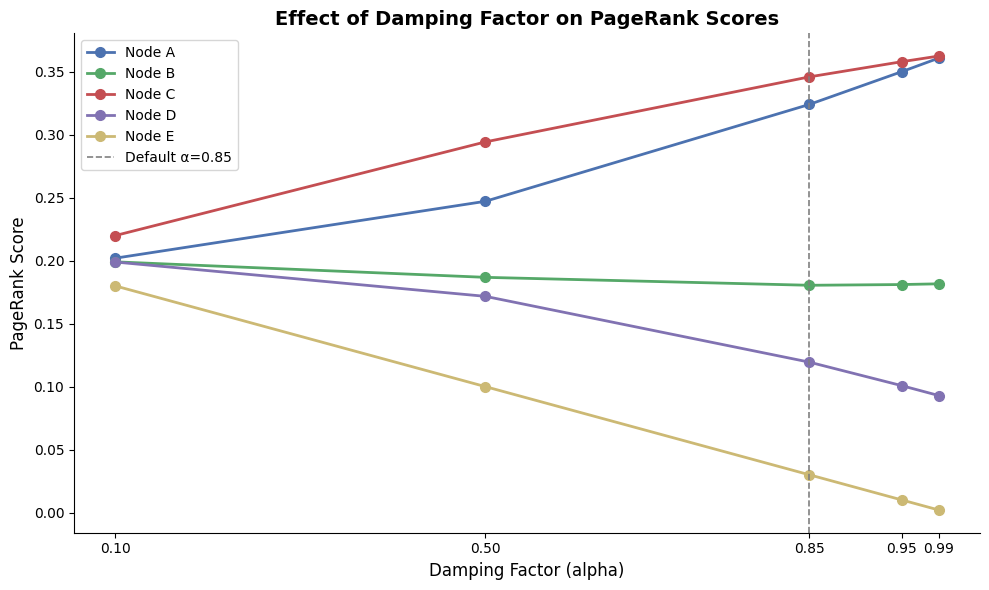

In [9]:
# Plot how each node's PageRank changes with alpha
fig, ax = plt.subplots(figsize=(10, 6))

node_colors_map = {'A': '#4C72B0', 'B': '#55A868', 'C': '#C44E52', 'D': '#8172B2', 'E': '#CCB974'}

for node in G.nodes():
    scores_by_alpha = [results[a][node] for a in alphas]
    ax.plot(alphas, scores_by_alpha, marker='o', label=f'Node {node}',
            color=node_colors_map[node], linewidth=2, markersize=7)

ax.axvline(x=0.85, color='gray', linestyle='--', linewidth=1.2, label='Default α=0.85')
ax.set_xlabel('Damping Factor (alpha)', fontsize=12)
ax.set_ylabel('PageRank Score', fontsize=12)
ax.set_title('Effect of Damping Factor on PageRank Scores', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(alphas)
plt.tight_layout()
plt.show()

### Key Observations

- **Low alpha (e.g. 0.1):** Scores converge toward uniform — graph structure matters less
- **High alpha (e.g. 0.99):** Scores amplify structural differences — popular nodes dominate even more
- **Default alpha = 0.85** balances structure with a realistic random-surfing model

> ✏️ **Try it yourself:** Modify the `alphas` list and re-run the cell to see how the plot changes!

---

## Section 8: Real-World Example — Karate Club Network

Now let's apply PageRank to a well-known social network dataset: **Zachary's Karate Club**.

This graph represents friendships between 34 members of a university karate club. It's a classic benchmark in network science, often used to study community structure.

In [10]:
# Load the Karate Club graph (built into NetworkX)
KG = nx.karate_club_graph()

# Convert to directed for PageRank
KG_directed = KG.to_directed()

print(f"Karate Club Graph: {KG.number_of_nodes()} members, {KG.number_of_edges()} friendships")

Karate Club Graph: 34 members, 78 friendships


In [11]:
# Compute PageRank on the Karate Club network
kc_pagerank = nx.pagerank(KG_directed, alpha=0.85)

# Show top 10 most important members
kc_df = pd.DataFrame(
    list(kc_pagerank.items()),
    columns=['Member ID', 'PageRank Score']
).sort_values('PageRank Score', ascending=False).reset_index(drop=True)

kc_df['Rank'] = kc_df.index + 1
kc_df['PageRank Score'] = kc_df['PageRank Score'].round(4)
kc_df = kc_df[['Rank', 'Member ID', 'PageRank Score']]

print("🥋 Top 10 Most Influential Members (by PageRank)")
print("=" * 40)
print(kc_df.head(10).to_string(index=False))

🥋 Top 10 Most Influential Members (by PageRank)
 Rank  Member ID  PageRank Score
    1         33          0.0970
    2          0          0.0885
    3         32          0.0759
    4          2          0.0628
    5          1          0.0574
    6         31          0.0420
    7         23          0.0411
    8          3          0.0372
    9          5          0.0338
   10         13          0.0335


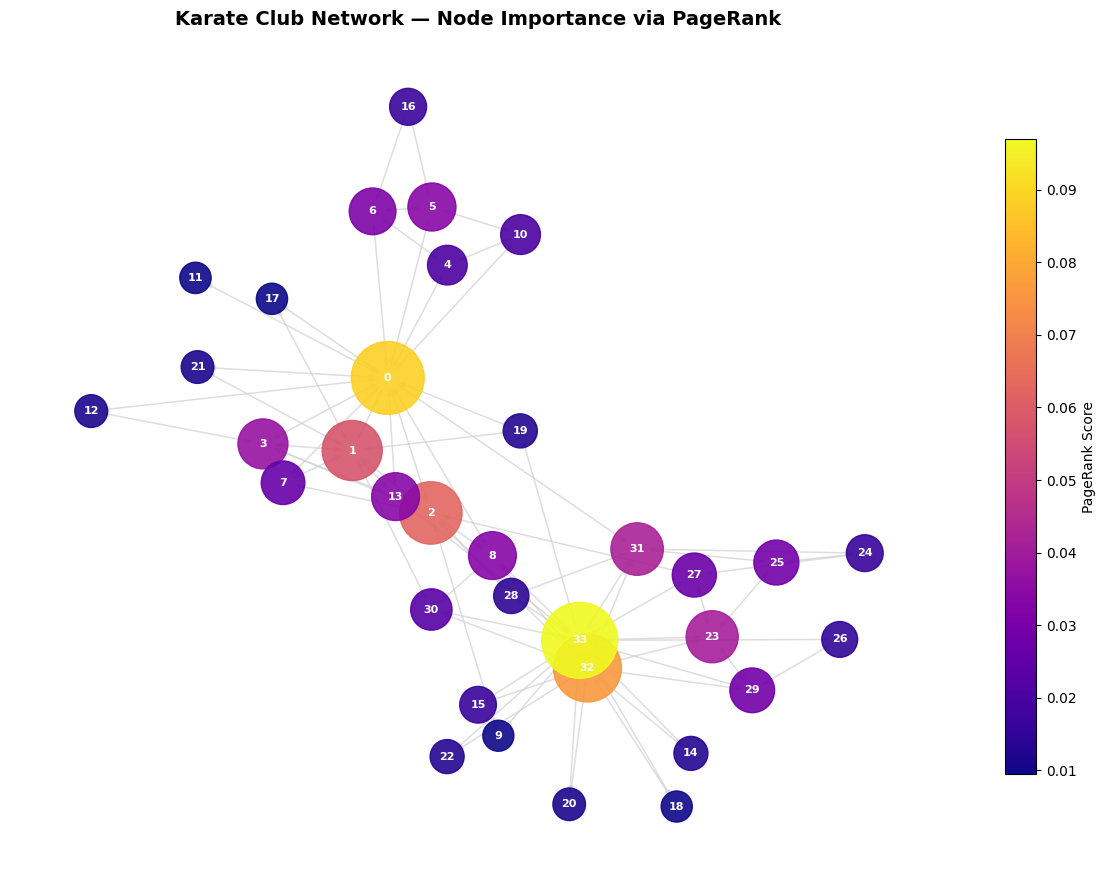

In [12]:
# Visualize the Karate Club network with PageRank-encoded node size and color
pr_values = np.array([kc_pagerank[n] for n in KG_directed.nodes()])
pr_norm = (pr_values - pr_values.min()) / (pr_values.max() - pr_values.min())

kc_sizes  = [500 + n * 2500 for n in pr_norm]
kc_colors = [plt.cm.plasma(n) for n in pr_norm]

fig, ax = plt.subplots(figsize=(12, 9))
pos_kc = nx.spring_layout(KG_directed, seed=42)

nx.draw_networkx_nodes(KG_directed, pos_kc, node_size=kc_sizes, node_color=kc_colors, ax=ax, alpha=0.9)
nx.draw_networkx_labels(KG_directed, pos_kc, font_size=8, font_color='white', font_weight='bold', ax=ax)
nx.draw_networkx_edges(
    KG_directed, pos_kc, edge_color='lightgray', alpha=0.5,
    arrows=True, arrowsize=8, ax=ax
)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma, norm=plt.Normalize(vmin=pr_values.min(), vmax=pr_values.max()))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='PageRank Score', shrink=0.75)

ax.set_title("Karate Club Network — Node Importance via PageRank", fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

### Interpretation

In the Karate Club graph:
- **Member 0** (the club instructor) and **Member 33** (the club president) typically dominate the PageRank rankings — they are the two known leaders of the club who ultimately caused the club to split into two factions
- Members with many connections to other well-connected members rank highly
- Peripheral members with few connections rank low

> 💡 **Historical note:** This dataset comes from Wayne Zachary's 1977 study. He correctly predicted which faction each member would join after the club split — based solely on the network structure!

---

### Interactive PageRank Experiment

To better understand how the damping factor affects PageRank scores,
we create a small function that allows us to run the algorithm with
different alpha values.

This makes experimentation easier and helps observe how the
importance scores change as the damping factor varies.

In [14]:
def run_pagerank(alpha):
    pr = nx.pagerank(G, alpha=alpha)
    
    print(f"\nPageRank scores with alpha = {alpha}\n")
    
    for node, score in pr.items():
        print(f"{node}: {score:.4f}")

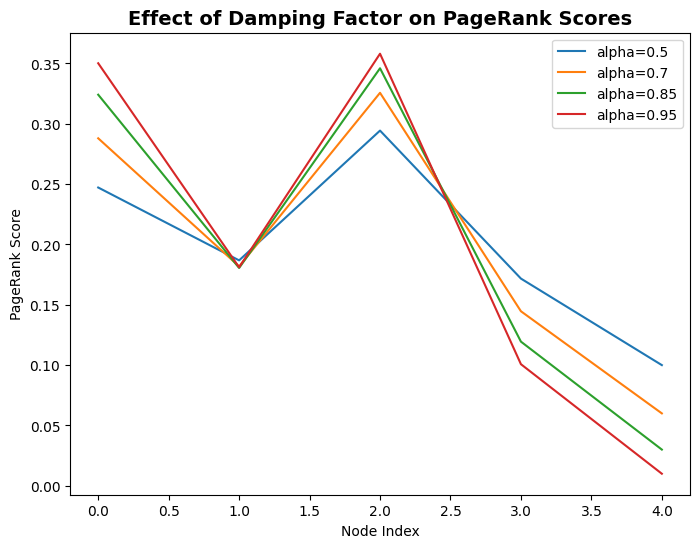

In [15]:
alphas = [0.5, 0.7, 0.85, 0.95]

for a in alphas:
    pr = nx.pagerank(G, alpha=a)
    values = list(pr.values())
    
    plt.plot(values, label=f"alpha={a}")

plt.title("Effect of Damping Factor on PageRank Scores")
plt.xlabel("Node Index")
plt.ylabel("PageRank Score")
plt.legend()
plt.show()

## Section 9: Summary

Congratulations! Here's what you've learned in this notebook:

| Topic | Key Takeaway |
|---|---|
| **PageRank Intuition** | Important nodes are those linked to by other important nodes |
| **Random Surfer Model** | PageRank = fraction of time a random walker spends at a node |
| **Damping Factor** | Controls the balance between structure and randomness |
| **NetworkX API** | `nx.pagerank(G, alpha=0.85)` computes PageRank in one line |
| **Visual Encoding** | Node size & color can encode importance intuitively |
| **Centrality Comparison** | PageRank, degree, and betweenness capture different notions of importance |
| **Real-World Application** | Applied to a real social network with meaningful results |

---

## Next Steps

Ready to go further? Here are some ideas:

1. **Try your own graph:** Replace the example edges with a network of your choice (citations, social media follows, road networks)
2. **Add interactive widgets:** Use `ipywidgets` to create sliders for the damping factor
3. **Explore other algorithms:** Look at `nx.hits()` for HITS (Hubs and Authorities), another famous link-analysis algorithm
4. **Use real data:** Download a dataset from [SNAP](https://snap.stanford.edu/data/) and apply PageRank to it

---

## References

- Brin, S. & Page, L. (1998). *The Anatomy of a Large-Scale Hypertextual Web Search Engine.*
- NetworkX Documentation: https://networkx.org/documentation/stable/reference/algorithms/link_analysis.html
- Zachary, W. (1977). *An information flow model for conflict and fission in small groups.*
